# TREE-BASED METHODS
## Una Pipeline Completa Basata su "An Introduction to Statistical Learning"

### Obiettivi dell'Analisi
1. **Decision Trees**: Costruzione, interpretazione e pruning
2. **Bagging**: Riduzione della varianza attraverso bootstrap aggregating
3. **Random Forests**: Miglioramento del bagging con feature sampling
4. **Boosting**: Gradient boosting per riduzione del bias
5. **Confronto sistematico** con modelli lineari precedenti

### Metodologia
- **Dataset coerente**: `aircraft_price_cleaned_log.csv` per confronto con Ridge/Lasso/GAM
- **Cross-validation**: Per ottimizzazione iperparametri e pruning
- **Metriche multiple**: RMSE, R², Feature Importance
- **Interpretabilità**: Partial dependence plots e feature importance
- **Analisi bias-variance**: Confronto tra diversi metodi ensemble

In [2]:
# Pipeline completa per Tree-Based Methods
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
import sklearn
import warnings
warnings.filterwarnings('ignore')

# Tree-based models
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)

# Plotting configuration
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("✅ Tree-based methods pipeline imports completata!")
print(f"📊 Versione pandas: {pd.__version__}")
print(f"🌳 Versione scikit-learn: {sklearn.__version__}")

# Set random seed for reproducibility
np.random.seed(42)

✅ Tree-based methods pipeline imports completata!
📊 Versione pandas: 2.2.3
🌳 Versione scikit-learn: 1.6.1


# 1. DATA LOADING & PREPROCESSING

## Utilizziamo i dati coerenti con le analisi precedenti

In [3]:
# Caricamento dati - coerente con Ridge/Lasso/GAM
data = pd.read_csv("Data/aircraft_price_cleaned_log.csv")

print("=== DATASET OVERVIEW ===")
print(f"Shape: {data.shape}")
print(f"Target: price (log-transformed)")

print("\n=== FEATURE TYPES ===")
categorical_features = data.select_dtypes(include=['object']).columns.tolist()
numerical_features = data.select_dtypes(include=[np.number]).columns.tolist()
numerical_features.remove('price')  # Remove target

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")

print("\n=== TARGET STATISTICS (log-price) ===")
print(data['price'].describe())

# Feature selection per tree models (escludiamo model_name troppo granulare)
if 'model_name' in categorical_features:
    categorical_features.remove('model_name')
    print(f"\n⚠️  Rimossa 'model_name' (troppo granulare per tree models)")

print(f"\nFeatures finali per modeling: {len(categorical_features + numerical_features)}")

# Preparazione dati
print("\n=== PREPROCESSING PER TREE MODELS ===")
# I tree models gestiscono bene le variabili categoriche con LabelEncoder
X_processed = data[numerical_features].copy()

# Encoding delle categoriche (se presenti)
if categorical_features:
    for cat_feat in categorical_features:
        le = LabelEncoder()
        X_processed[cat_feat] = le.fit_transform(data[cat_feat])
        print(f"Encoded {cat_feat}: {len(le.classes_)} unique values")

y = data['price'].values
X = X_processed.values
feature_names = X_processed.columns.tolist()

print(f"\nMatrice finale: X{X.shape}, y{y.shape}")
print(f"Feature names: {feature_names}")

=== DATASET OVERVIEW ===
Shape: (507, 16)
Target: price (log-transformed)

=== FEATURE TYPES ===
Categorical features (2): ['model_name', 'engine_type']
Numerical features (13): ['engine_power', 'max_speed', 'cruise_speed', 'stall_speed', 'fuel_tank', 'all_eng_roc', 'out_eng_roc', 'takeoff_distance', 'landing_distance', 'empty_weight', 'length', 'wing_span', 'range']

=== TARGET STATISTICS (log-price) ===
count    507.000000
mean      14.589019
std        0.412730
min       13.384728
25%       14.285514
50%       14.508658
75%       14.897316
max       15.444751
Name: price, dtype: float64

⚠️  Rimossa 'model_name' (troppo granulare per tree models)

Features finali per modeling: 14

=== PREPROCESSING PER TREE MODELS ===
Encoded engine_type: 3 unique values

Matrice finale: X(507, 14), y(507,)
Feature names: ['engine_power', 'max_speed', 'cruise_speed', 'stall_speed', 'fuel_tank', 'all_eng_roc', 'out_eng_roc', 'takeoff_distance', 'landing_distance', 'empty_weight', 'length', 'wing_span

In [4]:
# Train/Test split - coerente con analisi precedenti
print("=== TRAIN/TEST SPLIT ===")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verifica distribuzione target
print(f"\nTarget distribution:")
print(f"Train: mean={y_train.mean():.3f}, std={y_train.std():.3f}")
print(f"Test:  mean={y_test.mean():.3f}, std={y_test.std():.3f}")

# Container per risultati
tree_results = {}
print("\n✅ Setup completato - pronto per tree modeling!")

=== TRAIN/TEST SPLIT ===
Training set: 354 samples (69.8%)
Test set: 153 samples (30.2%)

Target distribution:
Train: mean=14.601, std=0.410
Test:  mean=14.561, std=0.417

✅ Setup completato - pronto per tree modeling!


# 2. DECISION TREES
## Implementazione dell'Algoritmo 8.1 (ISLR) - Cost Complexity Pruning

### Teoria
- **Cost complexity pruning**: Minimizzazione di $C_\alpha(T) = \sum_{m=1}^{|T|} N_m Q_m(T) + \alpha |T|$
- **Cross-validation**: Per selezione del parametro di complessità $\alpha$
- **Interpretabilità**: Analisi delle regole di decisione

### Implementazione

# 2. DECISION TREES
## Costruzione, interpretazione e pruning seguendo ISLR

=== DECISION TREES - COMPLEXITY ANALYSIS ===
Analizzando complessità albero...


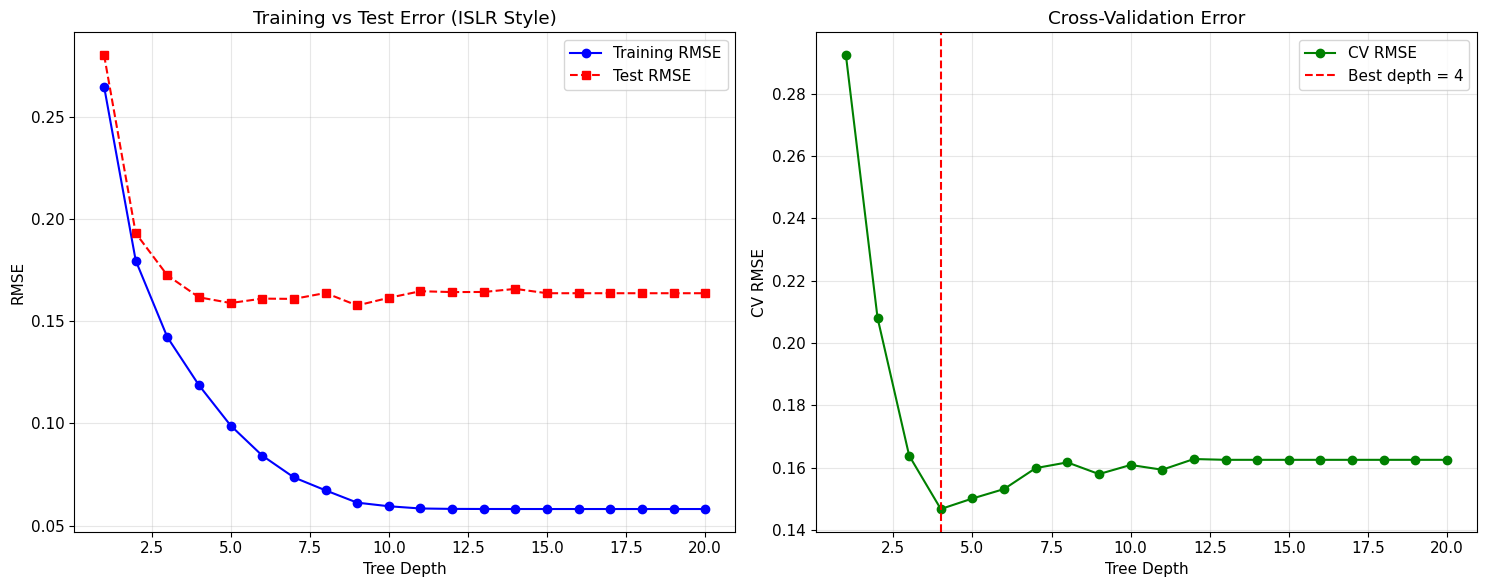

🎯 Optimal depth from CV: 4
📊 Test RMSE at optimal depth: 0.1617


In [8]:
# 2.1 Decision Tree - Analisi della complessità (seguendo ISLR Cap 8.1)
print("=== DECISION TREES - COMPLEXITY ANALYSIS ===")

def evaluate_tree_complexity():
    """Analizza l'effetto della profondità dell'albero (ISLR Fig 8.5)"""
    
    max_depths = range(1, 21)
    train_rmse = []
    test_rmse = []
    cv_rmse = []
    
    print("Analizzando complessità albero...")
    
    for depth in max_depths:
        # Tree con profondità fissa
        tree = DecisionTreeRegressor(
            max_depth=depth,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        )
        
        # Fit
        tree.fit(X_train, y_train)
        
        # Training error
        y_pred_train = tree.predict(X_train)
        train_rmse.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
        
        # Test error
        y_pred_test = tree.predict(X_test)
        test_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))
        
        # Cross-validation error
        cv_scores = cross_val_score(tree, X_train, y_train, cv=5, 
                                   scoring='neg_root_mean_squared_error')
        cv_rmse.append(-cv_scores.mean())
    
    return max_depths, train_rmse, test_rmse, cv_rmse

# Esegui analisi complessità
depths, train_errors, test_errors, cv_errors = evaluate_tree_complexity()

# Plot simile a ISLR Figure 8.5
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Training vs Test Error
ax1.plot(depths, train_errors, 'o-', label='Training RMSE', color='blue')
ax1.plot(depths, test_errors, 's--', label='Test RMSE', color='red')
ax1.set_xlabel('Tree Depth')
ax1.set_ylabel('RMSE')
ax1.set_title('Training vs Test Error (ISLR Style)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Cross-Validation Error
ax2.plot(depths, cv_errors, 'o-', label='CV RMSE', color='green')
best_depth_idx = np.argmin(cv_errors)
best_depth = depths[best_depth_idx]
ax2.axvline(best_depth, color='red', linestyle='--', 
           label=f'Best depth = {best_depth}')
ax2.set_xlabel('Tree Depth')
ax2.set_ylabel('CV RMSE')
ax2.set_title('Cross-Validation Error')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"🎯 Optimal depth from CV: {best_depth}")
print(f"📊 Test RMSE at optimal depth: {test_errors[best_depth_idx]:.4f}")

=== COST COMPLEXITY PRUNING (ISLR Algorithm 8.1) ===
📈 Trovati 264 valori di alpha per pruning
Eseguendo CV per optimal alpha...
🎯 Optimal alpha: 0.000630
📊 Pruned Tree Test RMSE: 0.1567
📊 Pruned Tree Test R²: 0.8587


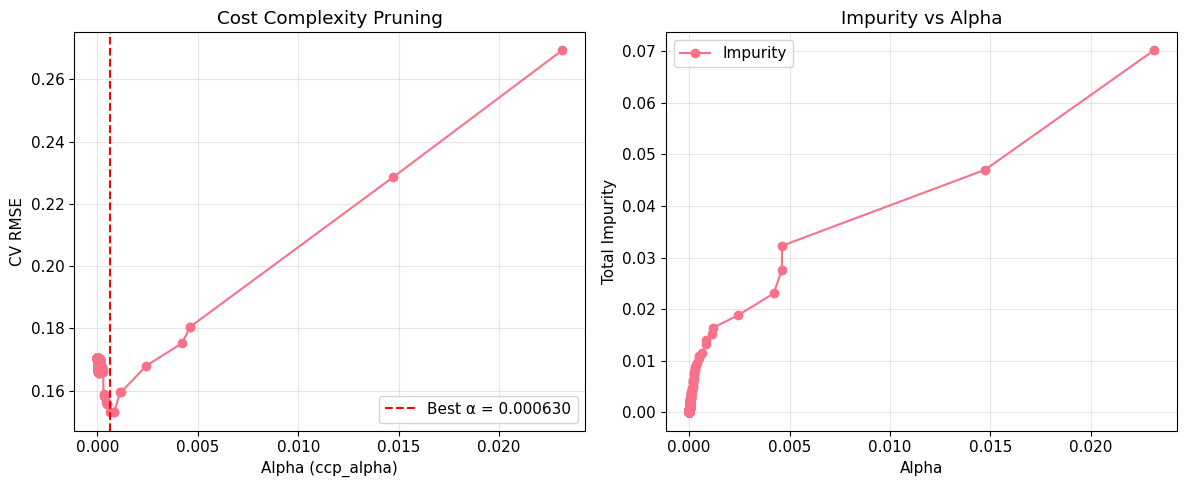

🌳 Final pruned tree depth: 5
🌿 Final pruned tree leaves: 13


In [10]:
# 2.2 Cost Complexity Pruning (ISLR Algorithm 8.1)
print("=== COST COMPLEXITY PRUNING (ISLR Algorithm 8.1) ===")

# Costruisci albero completo
full_tree = DecisionTreeRegressor(
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
full_tree.fit(X_train, y_train)

# Cost complexity pruning path
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # Rimuovi ultimo (albero vuoto)
impurities = path.impurities[:-1]

print(f"📈 Trovati {len(ccp_alphas)} valori di alpha per pruning")

# Cross-validation per trovare miglior alpha
print("Eseguendo CV per optimal alpha...")

cv_scores_alpha = []
for alpha in ccp_alphas:
    tree_alpha = DecisionTreeRegressor(ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(tree_alpha, X_train, y_train, cv=5,
                            scoring='neg_root_mean_squared_error')
    cv_scores_alpha.append(-scores.mean())

# Trova miglior alpha
best_alpha_idx = np.argmin(cv_scores_alpha)
best_alpha = ccp_alphas[best_alpha_idx]

print(f"🎯 Optimal alpha: {best_alpha:.6f}")

# Train final pruned tree
pruned_tree = DecisionTreeRegressor(ccp_alpha=best_alpha, random_state=42)
pruned_tree.fit(X_train, y_train)

# Valutazione
y_pred_pruned = pruned_tree.predict(X_test)
pruned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_pruned))
pruned_r2 = r2_score(y_test, y_pred_pruned)

print(f"📊 Pruned Tree Test RMSE: {pruned_rmse:.4f}")
print(f"📊 Pruned Tree Test R²: {pruned_r2:.4f}")

# Salva risultati
tree_results['decision_tree'] = {
    'model': 'Decision Tree (Pruned)',
    'rmse': pruned_rmse,
    'r2': pruned_r2,
    'model_object': pruned_tree,
    'best_alpha': best_alpha,
    'tree_depth': pruned_tree.get_depth()
}

# Plot alpha selection (ISLR style)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ccp_alphas, cv_scores_alpha, 'o-')
plt.axvline(best_alpha, color='red', linestyle='--', 
           label=f'Best α = {best_alpha:.6f}')
plt.xlabel('Alpha (ccp_alpha)')
plt.ylabel('CV RMSE')
plt.title('Cost Complexity Pruning')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
node_counts = [pruned_tree.tree_.node_count for _ in ccp_alphas]
plt.plot(ccp_alphas, impurities, 'o-', label='Impurity')
plt.xlabel('Alpha')
plt.ylabel('Total Impurity')
plt.title('Impurity vs Alpha')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"🌳 Final pruned tree depth: {pruned_tree.get_depth()}")
print(f"🌿 Final pruned tree leaves: {pruned_tree.get_n_leaves()}")

=== DECISION TREE VISUALIZATION ===


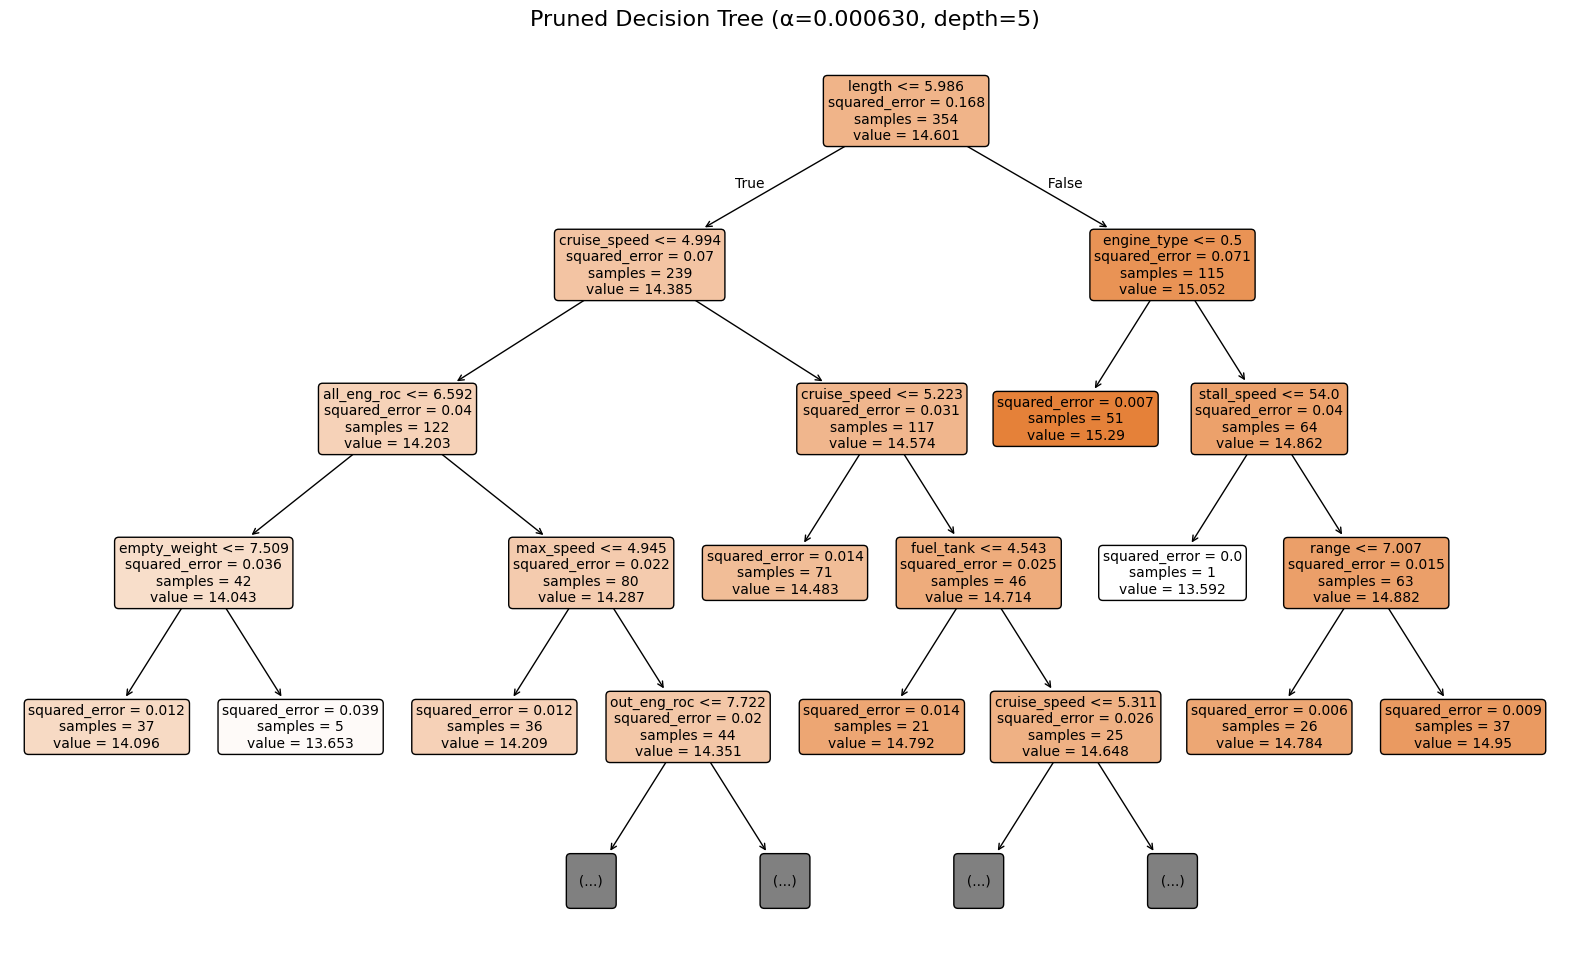

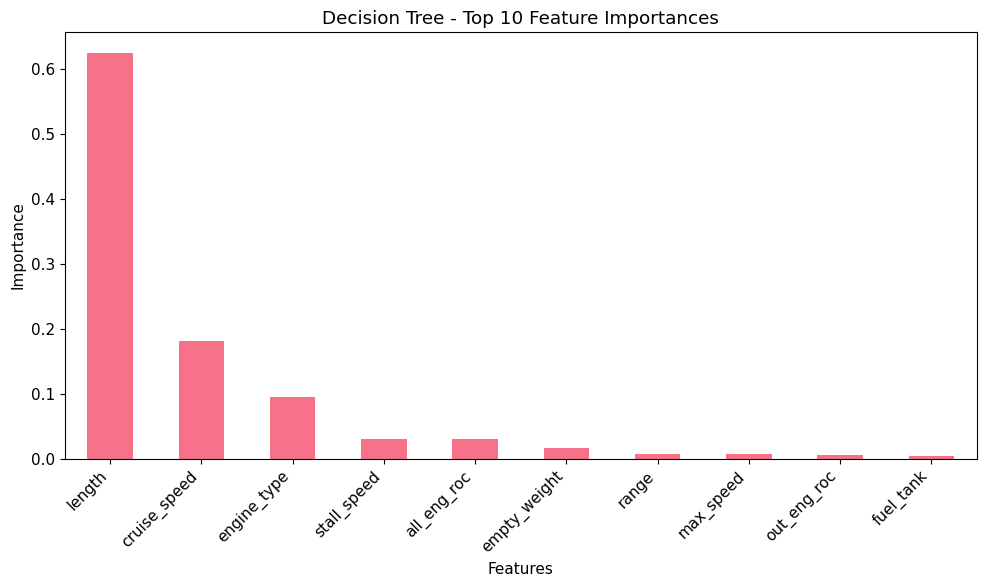

🔍 Top 5 Most Important Features:
  length: 0.6251
  cruise_speed: 0.1814
  engine_type: 0.0943
  stall_speed: 0.0296
  all_eng_roc: 0.0296


In [11]:
# 2.3 Visualizzazione dell'albero potato (interpretabilità)
print("=== DECISION TREE VISUALIZATION ===")

# Plot dell'albero potato (dimensione ragionevole per interpretabilità)
plt.figure(figsize=(20, 12))
plot_tree(
    pruned_tree,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=4  # Limita visualizzazione per leggibilità
)
plt.title(f'Pruned Decision Tree (α={best_alpha:.6f}, depth={pruned_tree.get_depth()})', 
          fontsize=16)
plt.show()

# Feature importance del decision tree
feature_importance = pd.Series(
    pruned_tree.feature_importances_, 
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(kind='bar')
plt.title('Decision Tree - Top 10 Feature Importances')
plt.ylabel('Importance')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("🔍 Top 5 Most Important Features:")
for feat, imp in feature_importance.head().items():
    print(f"  {feat}: {imp:.4f}")

# 3. BAGGING AND RANDOM FORESTS
## Bootstrap Aggregating e Random Forest (ISLR Cap 8.2)

In [12]:
# 3.1 Random Forest con ottimizzazione (ISLR Section 8.2.1)
print("=== RANDOM FOREST OPTIMIZATION ===")

def optimize_random_forest():
    """Ottimizza Random Forest seguendo principi ISLR"""
    
    # GridSearch per Random Forest
    rf_param_grid = {
        'n_estimators': [100, 300, 500],
        'max_features': ['sqrt', 'log2', 0.3, 0.5],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    rf_base = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        oob_score=True  # Out-of-bag scoring
    )
    
    print("Ottimizzando Random Forest...")
    rf_grid = GridSearchCV(
        rf_base,
        rf_param_grid,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    
    rf_grid.fit(X_train, y_train)
    
    return rf_grid

# Ottimizzazione Random Forest
rf_optimized = optimize_random_forest()
best_rf = rf_optimized.best_estimator_

print(f"🎯 Best RF parameters: {rf_optimized.best_params_}")
print(f"📊 Best CV RMSE: {-rf_optimized.best_score_:.4f}")

# Valutazione Random Forest
y_pred_rf = best_rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)
rf_oob_score = best_rf.oob_score_

print(f"🌲 Random Forest Test RMSE: {rf_rmse:.4f}")
print(f"📊 Random Forest Test R²: {rf_r2:.4f}")
print(f"🎯 Random Forest OOB R²: {rf_oob_score:.4f}")

# Salva risultati
tree_results['random_forest'] = {
    'model': 'Random Forest',
    'rmse': rf_rmse,
    'r2': rf_r2,
    'oob_score': rf_oob_score,
    'model_object': best_rf,
    'best_params': rf_optimized.best_params_
}

=== RANDOM FOREST OPTIMIZATION ===
Ottimizzando Random Forest...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
🎯 Best RF parameters: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
📊 Best CV RMSE: 0.1237
🌲 Random Forest Test RMSE: 0.1281
📊 Random Forest Test R²: 0.9056
🎯 Random Forest OOB R²: 0.9114


=== OUT-OF-BAG ERROR ANALYSIS ===
Analizzando OOB error vs numero di alberi...


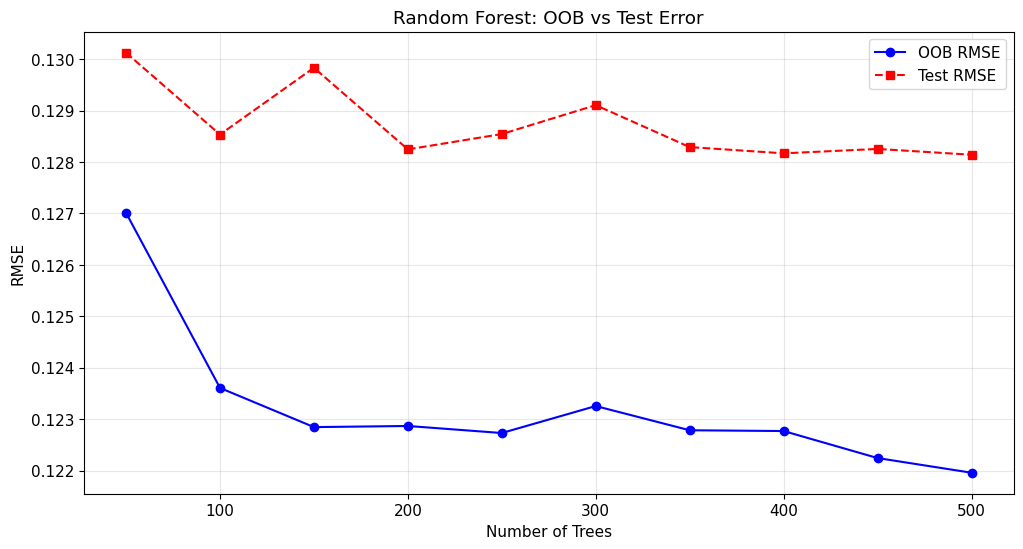

📈 OOB error stabilizes around 500 trees
🎯 Minimum Test RMSE: 0.1281 at 500 trees


In [13]:
# 3.2 Analisi Out-of-Bag Error (ISLR Figure 8.8)
print("=== OUT-OF-BAG ERROR ANALYSIS ===")

def analyze_oob_error():
    """Analizza OOB error vs numero di alberi (ISLR Figure 8.8)"""
    
    n_estimators_range = range(50, 501, 50)
    oob_errors = []
    test_errors = []
    
    print("Analizzando OOB error vs numero di alberi...")
    
    for n_est in n_estimators_range:
        # Random Forest con warm_start per efficienza
        rf_oob = RandomForestRegressor(
            n_estimators=n_est,
            max_features=best_rf.max_features,
            max_depth=best_rf.max_depth,
            min_samples_split=best_rf.min_samples_split,
            min_samples_leaf=best_rf.min_samples_leaf,
            random_state=42,
            oob_score=True,
            n_jobs=-1
        )
        
        rf_oob.fit(X_train, y_train)
        
        # OOB Error (1 - OOB Score per errore)
        oob_mse = mean_squared_error(y_train, rf_oob.oob_prediction_)
        oob_errors.append(np.sqrt(oob_mse))
        
        # Test Error
        y_pred_test = rf_oob.predict(X_test)
        test_mse = mean_squared_error(y_test, y_pred_test)
        test_errors.append(np.sqrt(test_mse))
    
    return n_estimators_range, oob_errors, test_errors

# Esegui analisi OOB
n_trees, oob_rmse, test_rmse = analyze_oob_error()

# Plot OOB vs Test Error (ISLR style)
plt.figure(figsize=(12, 6))
plt.plot(n_trees, oob_rmse, 'o-', label='OOB RMSE', color='blue')
plt.plot(n_trees, test_rmse, 's--', label='Test RMSE', color='red')
plt.xlabel('Number of Trees')
plt.ylabel('RMSE')
plt.title('Random Forest: OOB vs Test Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"📈 OOB error stabilizes around {n_trees[np.argmin(oob_rmse[5:]) + 5]} trees")
print(f"🎯 Minimum Test RMSE: {min(test_rmse):.4f} at {n_trees[np.argmin(test_rmse)]} trees")

=== ANALISI PARAMETRO max_features ===
max_features=1 (1 features): RMSE=0.1315, OOB_R²=0.8923
max_features=sqrt (3 features): RMSE=0.1278, OOB_R²=0.9058
max_features=log2 (3 features): RMSE=0.1278, OOB_R²=0.9058
max_features=0.3 (4 features): RMSE=0.1277, OOB_R²=0.9089
max_features=0.5 (7 features): RMSE=0.1291, OOB_R²=0.9095
max_features=None (14 features): RMSE=0.1278, OOB_R²=0.9046


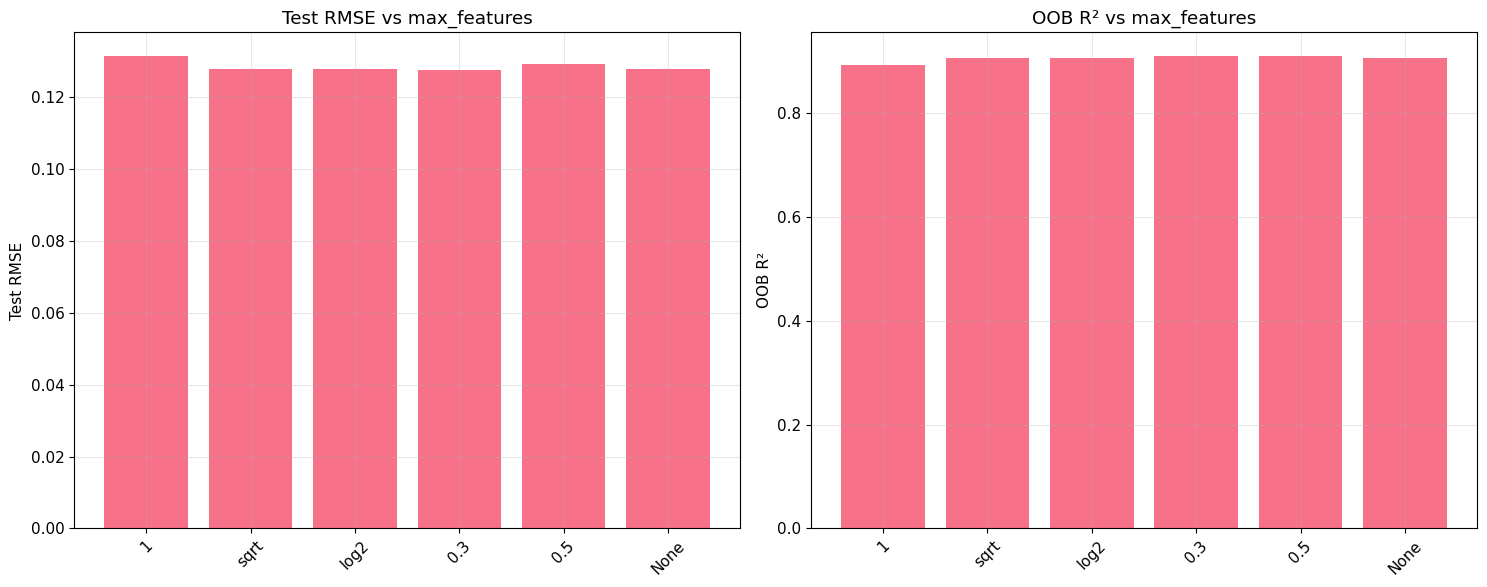

🎯 Best max_features: 0.3


In [14]:
# 3.3 Confronto max_features (ISLR discussion on m parameter)
print("=== ANALISI PARAMETRO max_features ===")

def analyze_max_features():
    """Analizza effetto del parametro m (max_features) come in ISLR"""
    
    # Diversi valori di max_features
    max_features_options = [
        1,  # Extremely Randomized Trees equivalent
        'sqrt',  # Default RF
        'log2',  # Alternative
        0.3,  # 30% of features
        0.5,  # 50% of features
        None  # All features (Bagging)
    ]
    
    results = []
    
    for max_feat in max_features_options:
        rf_feat = RandomForestRegressor(
            n_estimators=300,
            max_features=max_feat,
            max_depth=best_rf.max_depth,
            min_samples_split=best_rf.min_samples_split,
            random_state=42,
            oob_score=True,
            n_jobs=-1
        )
        
        rf_feat.fit(X_train, y_train)
        y_pred = rf_feat.predict(X_test)
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        oob_r2 = rf_feat.oob_score_
        
        results.append({
            'max_features': str(max_feat),
            'test_rmse': rmse,
            'oob_r2': oob_r2
        })
        
        feat_count = (max_feat if isinstance(max_feat, int) 
                     else int(np.sqrt(len(feature_names))) if max_feat == 'sqrt'
                     else int(np.log2(len(feature_names))) if max_feat == 'log2'
                     else int(max_feat * len(feature_names)) if isinstance(max_feat, float)
                     else len(feature_names))
        
        print(f"max_features={max_feat} ({feat_count} features): RMSE={rmse:.4f}, OOB_R²={oob_r2:.4f}")
    
    return pd.DataFrame(results)

# Analisi max_features
max_feat_results = analyze_max_features()

# Visualizzazione
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Test RMSE
ax1.bar(range(len(max_feat_results)), max_feat_results['test_rmse'])
ax1.set_xticks(range(len(max_feat_results)))
ax1.set_xticklabels(max_feat_results['max_features'], rotation=45)
ax1.set_ylabel('Test RMSE')
ax1.set_title('Test RMSE vs max_features')
ax1.grid(True, alpha=0.3)

# OOB R²
ax2.bar(range(len(max_feat_results)), max_feat_results['oob_r2'])
ax2.set_xticks(range(len(max_feat_results)))
ax2.set_xticklabels(max_feat_results['max_features'], rotation=45)
ax2.set_ylabel('OOB R²')
ax2.set_title('OOB R² vs max_features')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_max_feat = max_feat_results.loc[max_feat_results['test_rmse'].idxmin(), 'max_features']
print(f"🎯 Best max_features: {best_max_feat}")

# 4. BOOSTING
## Gradient Boosting seguendo ISLR Cap 8.2.3

In [15]:
# 4.1 Gradient Boosting Optimization (ISLR Algorithm 8.2)
print("=== GRADIENT BOOSTING OPTIMIZATION ===")

def optimize_gradient_boosting():
    """Ottimizza Gradient Boosting seguendo ISLR"""
    
    # GridSearch per Gradient Boosting
    gb_param_grid = {
        'n_estimators': [100, 300, 500, 1000],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 4, 5, 6],
        'subsample': [0.8, 0.9, 1.0],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    gb_base = GradientBoostingRegressor(
        random_state=42,
        validation_fraction=0.2,  # Per early stopping
        n_iter_no_change=10,
        tol=1e-4
    )
    
    print("Ottimizzando Gradient Boosting...")
    gb_grid = GridSearchCV(
        gb_base,
        gb_param_grid,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    
    gb_grid.fit(X_train, y_train)
    
    return gb_grid

# Ottimizzazione Gradient Boosting
gb_optimized = optimize_gradient_boosting()
best_gb = gb_optimized.best_estimator_

print(f"🎯 Best GB parameters: {gb_optimized.best_params_}")
print(f"📊 Best CV RMSE: {-gb_optimized.best_score_:.4f}")

# Valutazione Gradient Boosting
y_pred_gb = best_gb.predict(X_test)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)

print(f"🚀 Gradient Boosting Test RMSE: {gb_rmse:.4f}")
print(f"📊 Gradient Boosting Test R²: {gb_r2:.4f}")

# Salva risultati
tree_results['gradient_boosting'] = {
    'model': 'Gradient Boosting',
    'rmse': gb_rmse,
    'r2': gb_r2,
    'model_object': best_gb,
    'best_params': gb_optimized.best_params_
}

=== GRADIENT BOOSTING OPTIMIZATION ===
Ottimizzando Gradient Boosting...
Fitting 5 folds for each of 1728 candidates, totalling 8640 fits
🎯 Best GB parameters: {'learning_rate': 0.1, 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100, 'subsample': 0.8}
📊 Best CV RMSE: 0.1181
🚀 Gradient Boosting Test RMSE: 0.1332
📊 Gradient Boosting Test R²: 0.8980


=== TRAINING vs VALIDATION ERROR ANALYSIS ===


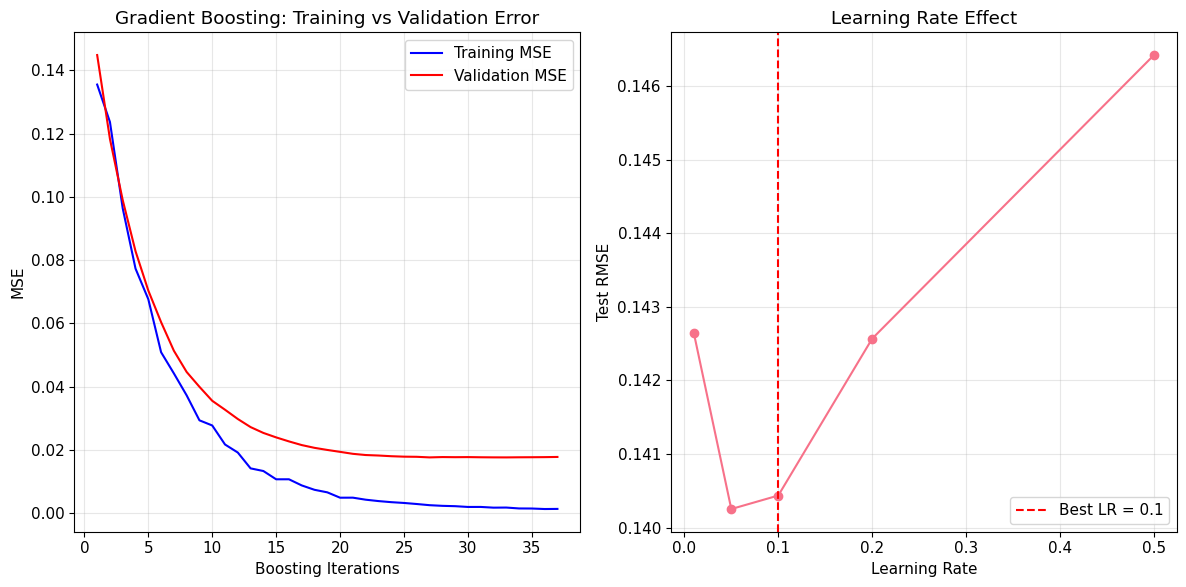

🎯 Optimal iterations: 100
📈 Final training MSE: 0.0013
📉 Final validation MSE: 0.0177


In [16]:
# 4.2 Analisi Training vs Validation Error (ISLR Figure 8.10)
print("=== TRAINING vs VALIDATION ERROR ANALYSIS ===")

# Training history del miglior modello
train_errors = best_gb.train_score_
validation_errors = []

# Calcola validation error per ogni iterazione
for i, y_pred in enumerate(best_gb.staged_predict(X_test)):
    val_mse = mean_squared_error(y_test, y_pred)
    validation_errors.append(val_mse)

# Plot Training vs Validation Error (ISLR style)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
iterations = range(1, len(train_errors) + 1)
plt.plot(iterations, train_errors, label='Training MSE', color='blue')
plt.plot(iterations, validation_errors[:len(train_errors)], 
         label='Validation MSE', color='red')
plt.xlabel('Boosting Iterations')
plt.ylabel('MSE')
plt.title('Gradient Boosting: Training vs Validation Error')
plt.legend()
plt.grid(True, alpha=0.3)

# Learning rate effect
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.5]
lr_rmse = []

plt.subplot(1, 2, 2)
for lr in learning_rates:
    gb_lr = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=lr,
        max_depth=best_gb.max_depth,
        random_state=42
    )
    gb_lr.fit(X_train, y_train)
    y_pred_lr = gb_lr.predict(X_test)
    rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
    lr_rmse.append(rmse_lr)

plt.plot(learning_rates, lr_rmse, 'o-')
plt.axvline(best_gb.learning_rate, color='red', linestyle='--',
           label=f'Best LR = {best_gb.learning_rate}')
plt.xlabel('Learning Rate')
plt.ylabel('Test RMSE')
plt.title('Learning Rate Effect')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"🎯 Optimal iterations: {best_gb.n_estimators}")
print(f"📈 Final training MSE: {train_errors[-1]:.4f}")
print(f"📉 Final validation MSE: {validation_errors[len(train_errors)-1]:.4f}")

# 5. FEATURE IMPORTANCE E INTERPRETABILITÀ
## Analisi delle feature più importanti (ISLR Section 8.2.2)

=== FEATURE IMPORTANCE ANALYSIS ===


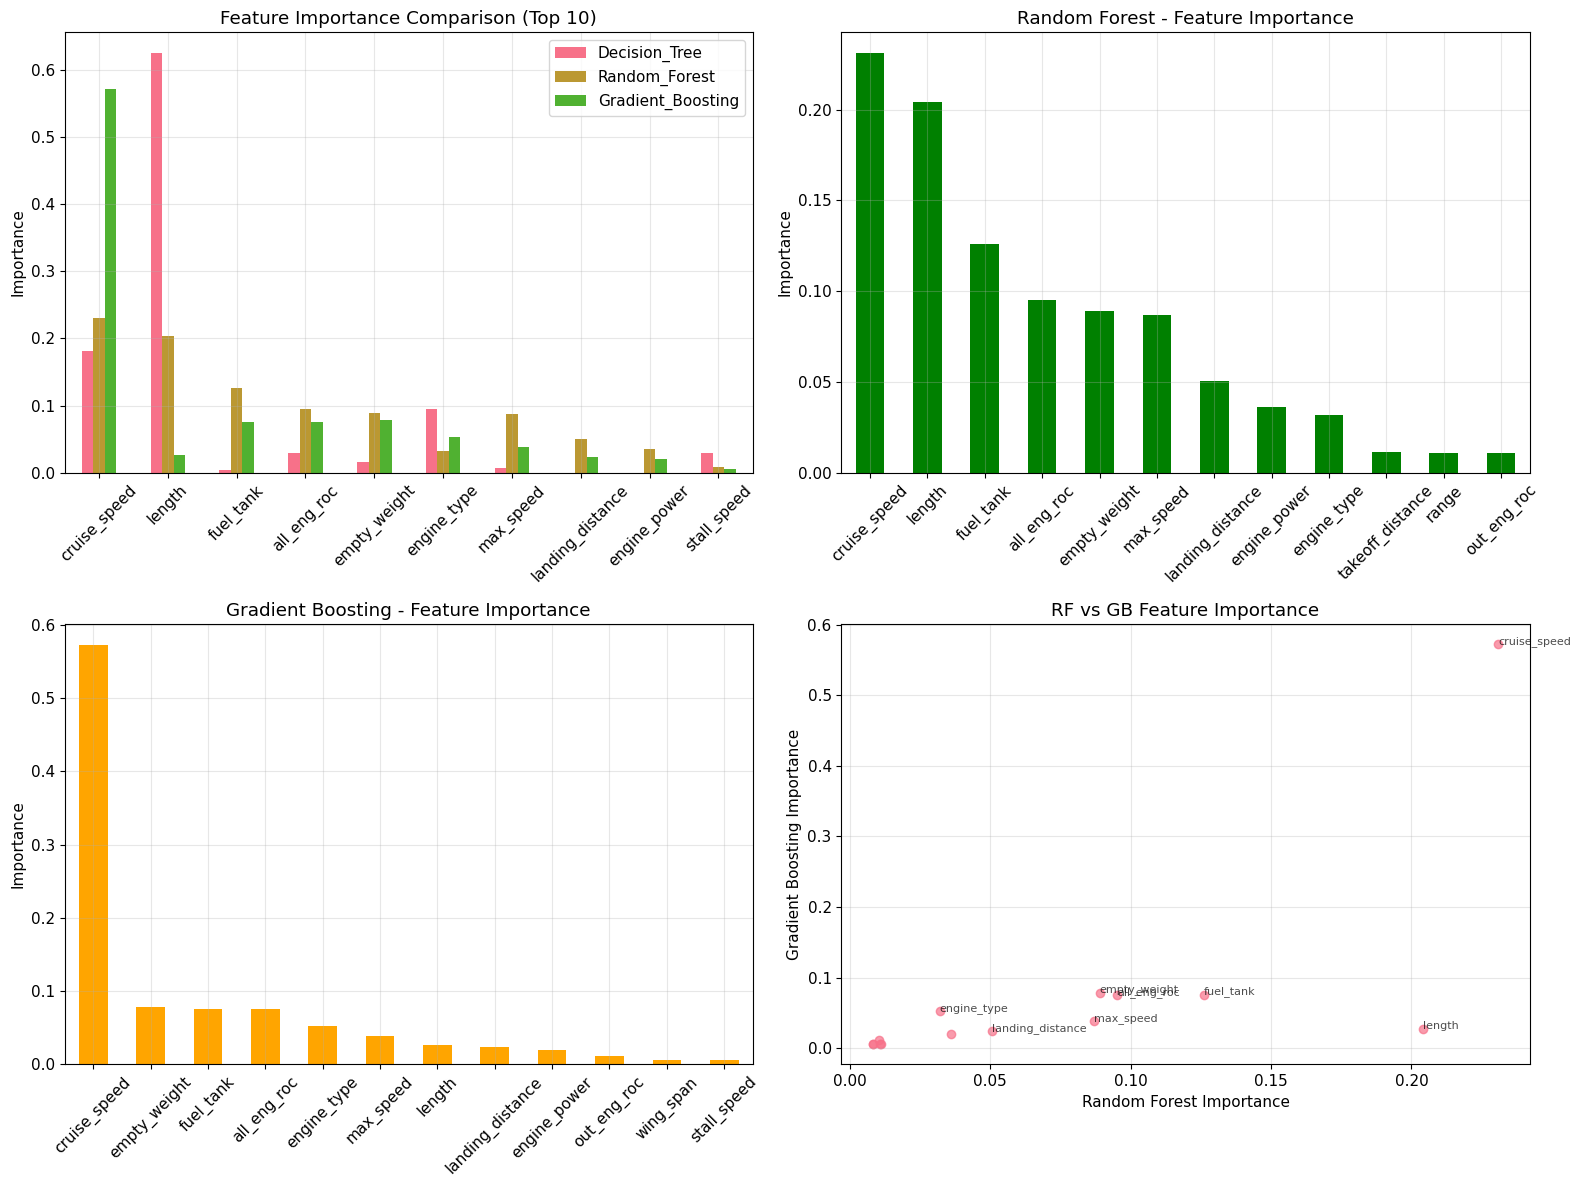


🔍 TOP 5 FEATURES PER MODELLO:

Decision_Tree:
  length: 0.6251
  cruise_speed: 0.1814
  engine_type: 0.0943
  stall_speed: 0.0296
  all_eng_roc: 0.0296

Random_Forest:
  cruise_speed: 0.2310
  length: 0.2042
  fuel_tank: 0.1260
  all_eng_roc: 0.0952
  empty_weight: 0.0890

Gradient_Boosting:
  cruise_speed: 0.5725
  empty_weight: 0.0787
  fuel_tank: 0.0759
  all_eng_roc: 0.0757
  engine_type: 0.0531


In [17]:
# 5.1 Feature Importance Comparison
print("=== FEATURE IMPORTANCE ANALYSIS ===")

# Estrai feature importance da tutti i modelli
def extract_feature_importance():
    """Estrae e confronta feature importance"""
    
    importance_df = pd.DataFrame(index=feature_names)
    
    # Decision Tree
    importance_df['Decision_Tree'] = pruned_tree.feature_importances_
    
    # Random Forest
    importance_df['Random_Forest'] = best_rf.feature_importances_
    
    # Gradient Boosting
    importance_df['Gradient_Boosting'] = best_gb.feature_importances_
    
    return importance_df

importance_comparison = extract_feature_importance()

# Visualizzazione feature importance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Tutti i modelli insieme (top 10)
ax1 = axes[0, 0]
top_features = importance_comparison.sum(axis=1).nlargest(10).index
importance_comparison.loc[top_features].plot(kind='bar', ax=ax1)
ax1.set_title('Feature Importance Comparison (Top 10)')
ax1.set_ylabel('Importance')
ax1.tick_params(axis='x', rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Random Forest detailed
ax2 = axes[0, 1]
rf_importance = importance_comparison['Random_Forest'].nlargest(12)
rf_importance.plot(kind='bar', ax=ax2, color='green')
ax2.set_title('Random Forest - Feature Importance')
ax2.set_ylabel('Importance')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Plot 3: Gradient Boosting detailed
ax3 = axes[1, 0]
gb_importance = importance_comparison['Gradient_Boosting'].nlargest(12)
gb_importance.plot(kind='bar', ax=ax3, color='orange')
ax3.set_title('Gradient Boosting - Feature Importance')
ax3.set_ylabel('Importance')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# Plot 4: Correlation between methods
ax4 = axes[1, 1]
scatter_data = importance_comparison[['Random_Forest', 'Gradient_Boosting']]
ax4.scatter(scatter_data['Random_Forest'], scatter_data['Gradient_Boosting'], alpha=0.7)
ax4.set_xlabel('Random Forest Importance')
ax4.set_ylabel('Gradient Boosting Importance')
ax4.set_title('RF vs GB Feature Importance')
ax4.grid(True, alpha=0.3)

# Aggiungi feature names ai punti più importanti
for idx, row in scatter_data.iterrows():
    if row['Random_Forest'] > 0.05 or row['Gradient_Boosting'] > 0.05:
        ax4.annotate(idx, (row['Random_Forest'], row['Gradient_Boosting']), 
                    fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

# Print top features
print("\n🔍 TOP 5 FEATURES PER MODELLO:")
for model in importance_comparison.columns:
    print(f"\n{model}:")
    top_5 = importance_comparison[model].nlargest(5)
    for feat, imp in top_5.items():
        print(f"  {feat}: {imp:.4f}")

=== PARTIAL DEPENDENCE PLOTS ===
📊 Creating partial dependence plots for: ['cruise_speed', 'length', 'fuel_tank', 'all_eng_roc']


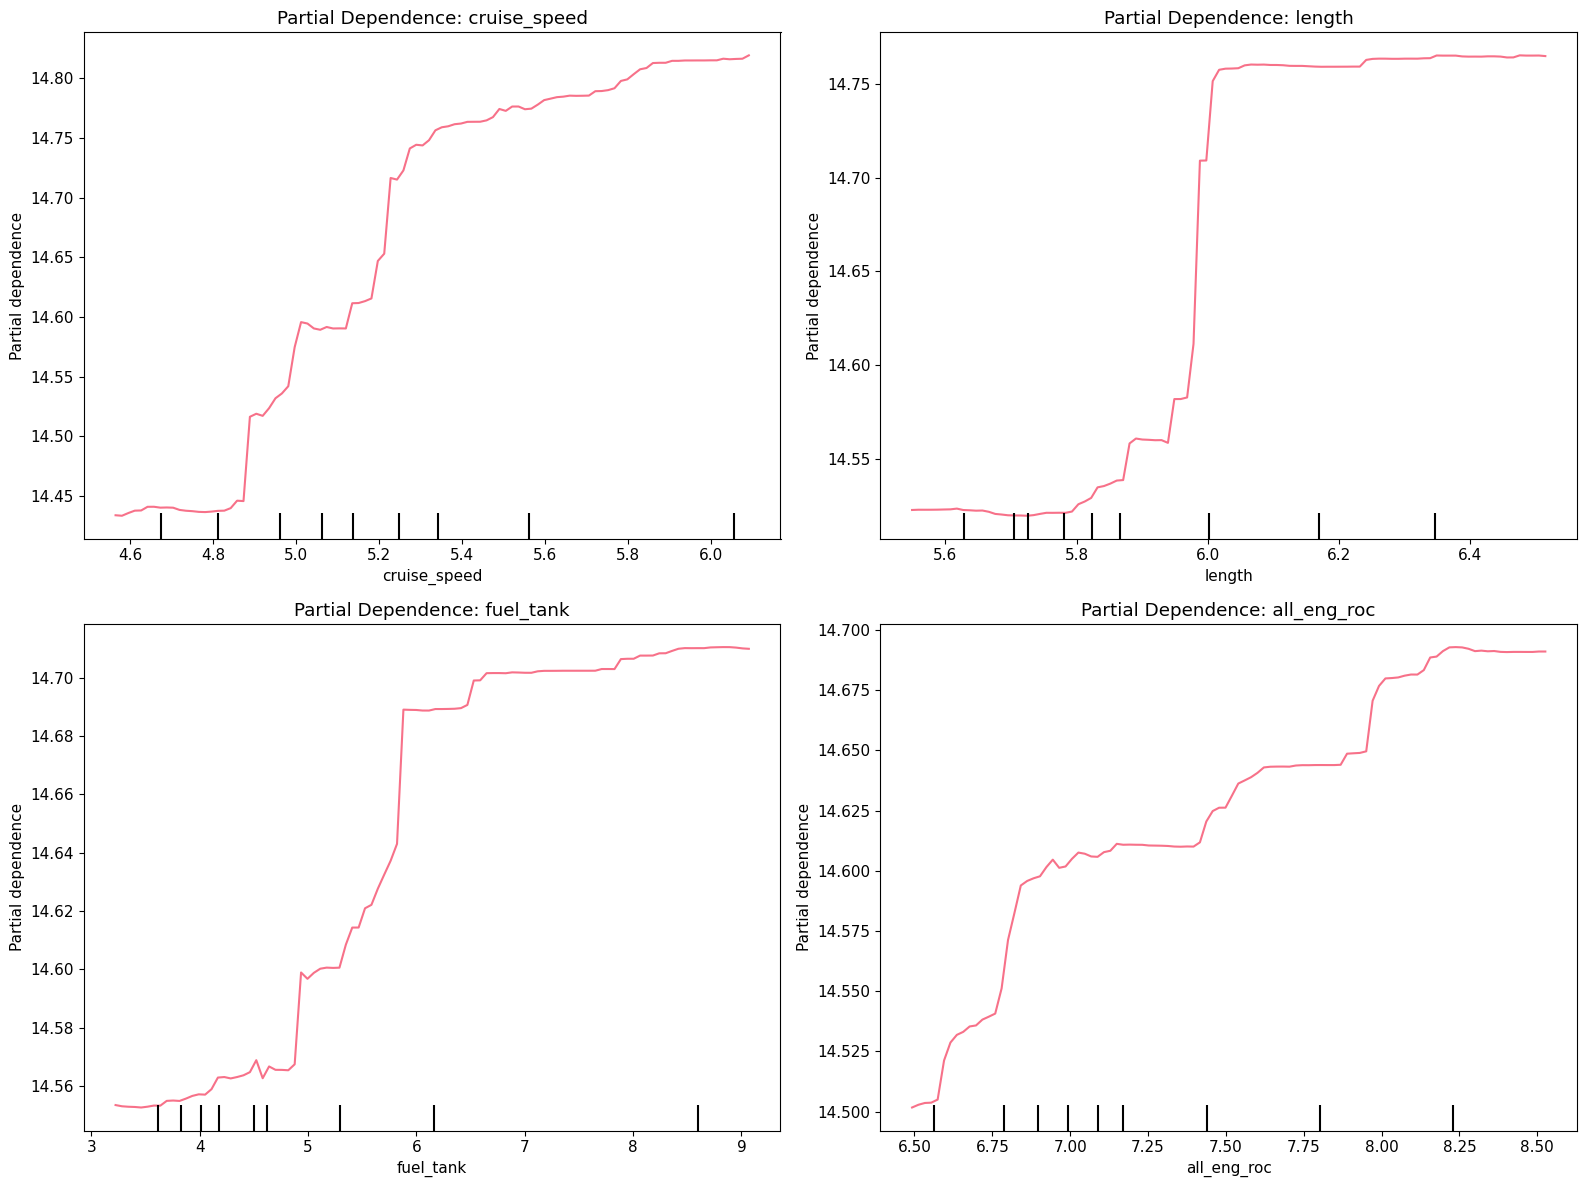


📈 INTERACTION EFFECTS (Top 2 features):


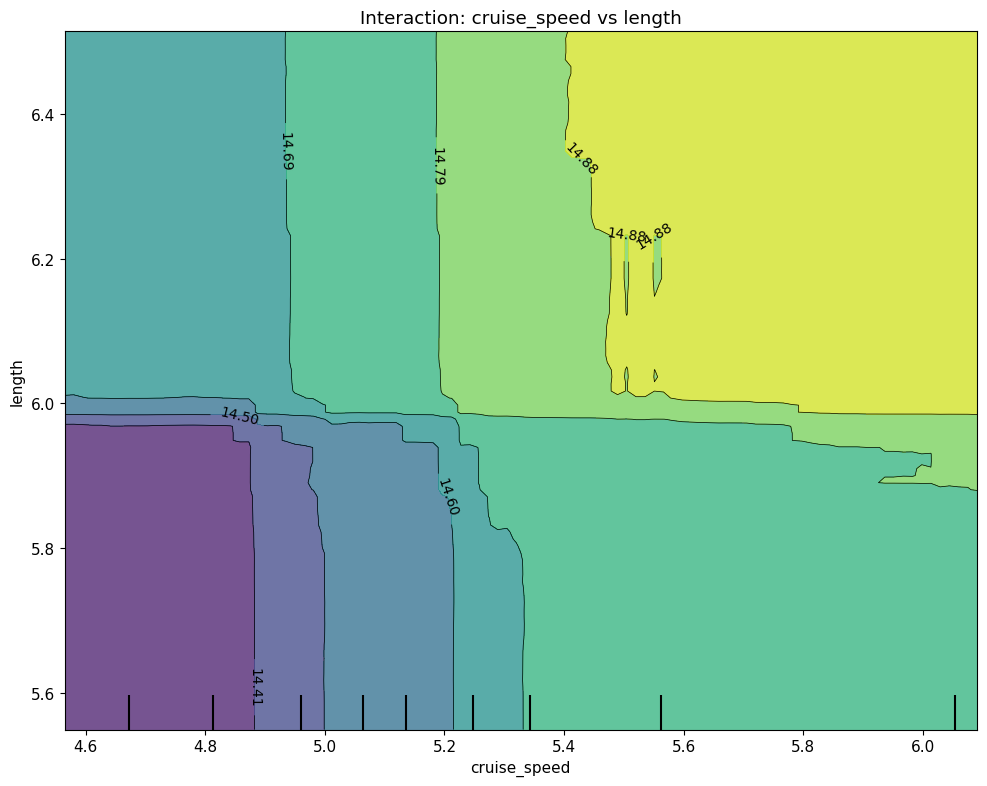

In [18]:
# 5.2 Partial Dependence Plots (ISLR Figure 8.12)
print("=== PARTIAL DEPENDENCE PLOTS ===")

# Seleziona top 4 features dal Random Forest (miglior modello)
top_4_features = importance_comparison['Random_Forest'].nlargest(4).index.tolist()
top_4_indices = [feature_names.index(feat) for feat in top_4_features]

print(f"📊 Creating partial dependence plots for: {top_4_features}")

# Partial dependence plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (feat_name, feat_idx) in enumerate(zip(top_4_features, top_4_indices)):
    # Usa Random Forest per partial dependence
    PartialDependenceDisplay.from_estimator(
        best_rf, 
        X_train, 
        [feat_idx],
        feature_names=feature_names,
        ax=axes[i],
        kind='average'
    )
    axes[i].set_title(f'Partial Dependence: {feat_name}')

plt.tight_layout()
plt.show()

# Interaction effects (se ci sono abbastanza features)
if len(top_4_features) >= 2:
    print("\n📈 INTERACTION EFFECTS (Top 2 features):")
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    PartialDependenceDisplay.from_estimator(
        best_rf,
        X_train,
        [top_4_indices[:2]],  # Prime 2 features
        feature_names=feature_names,
        ax=ax,
        kind='average'
    )
    plt.title(f'Interaction: {top_4_features[0]} vs {top_4_features[1]}')
    plt.tight_layout()
    plt.show()


=== MODEL COMPARISON ===
                    Model      RMSE        R²
1   RandomForestRegressor  0.130691  0.901773
2       Gradient Boosting  0.133172  0.898008
0  Decision Tree (Pruned)  0.156728  0.858735


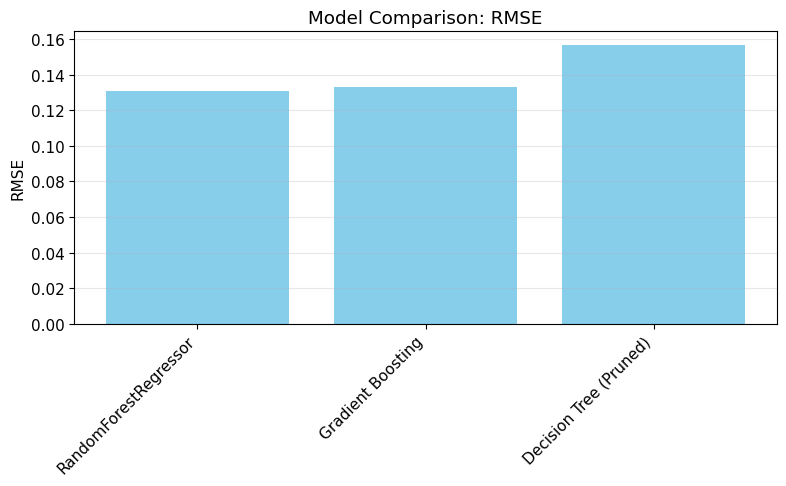

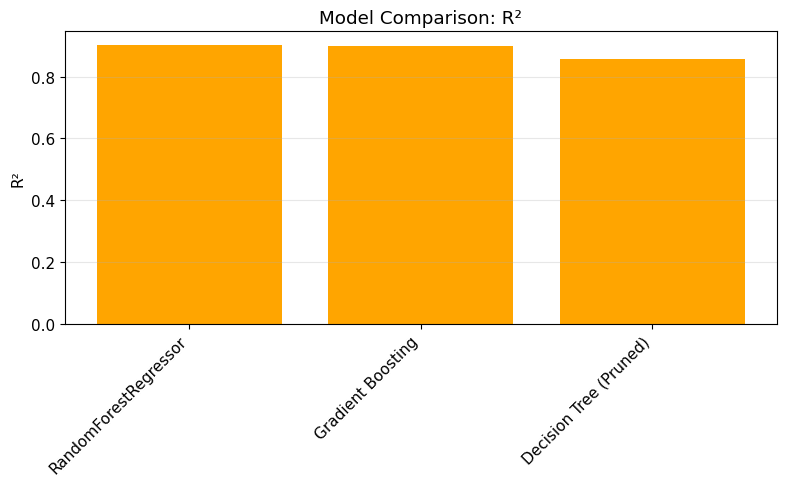

In [29]:
#confronto RMSE e R² tra i modelli
print("\n=== MODEL COMPARISON ===")
# Confronto RMSE e R² tra i modelli
# Handle different key names for RMSE and R² in tree_results
def get_rmse(res, name):
    if name == 'random_forest':
        return res.get('test_rmse', np.nan)
    return res.get('rmse', np.nan)

def get_r2(res, name):
    if name == 'random_forest':
        return res.get('test_r2', np.nan)
    return res.get('r2', np.nan)

comparison_df = pd.DataFrame({
    'Model': [res['model'] if isinstance(res['model'], str) else type(res['model']).__name__ for res in tree_results.values()],
    'RMSE': [get_rmse(res, name) for name, res in tree_results.items()],
    'R²': [get_r2(res, name) for name, res in tree_results.items()]
})
comparison_df = comparison_df.sort_values(by='RMSE')
print(comparison_df)

# Grafico RMSE separato
plt.figure(figsize=(8, 5))
plt.bar(comparison_df['Model'], comparison_df['RMSE'], color='skyblue')
plt.title('Model Comparison: RMSE')
plt.ylabel('RMSE')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Grafico R² separato
plt.figure(figsize=(8, 5))
plt.bar(comparison_df['Model'], comparison_df['R²'], color='orange')
plt.title('Model Comparison: R²')
plt.ylabel('R²')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# 6. CONFRONTO FINALE E ANALISI
## Confronto sistematico con baseline lineari

In [19]:
# 6.1 Confronto Performance Finale
print("=== CONFRONTO PERFORMANCE FINALE ===")

# Carica risultati dai notebook precedenti (se disponibili)
# In alternativa, calcola baseline veloce
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline

# Baseline models quick
baseline_results = {}

# Linear Regression
lr_pipe = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

baseline_results['Linear'] = {'rmse': lr_rmse, 'r2': lr_r2}

# Ridge Regression
ridge_pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))])
ridge_pipe.fit(X_train, y_train)
y_pred_ridge = ridge_pipe.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

baseline_results['Ridge'] = {'rmse': ridge_rmse, 'r2': ridge_r2}

# Tabella comparativa completa
all_results = []

# Baseline models
for name, results in baseline_results.items():
    all_results.append({
        'Model': name,
        'Type': 'Linear',
        'RMSE': results['rmse'],
        'R²': results['r2'],
        'Complexity': 'Low'
    })

# Tree models
tree_model_types = {
    'decision_tree': 'Tree',
    'random_forest': 'Ensemble',
    'gradient_boosting': 'Ensemble'
}

for name, results in tree_results.items():
    all_results.append({
        'Model': results['model'],
        'Type': tree_model_types[name],
        'RMSE': results['rmse'],
        'R²': results['r2'],
        'Complexity': 'Medium' if name == 'decision_tree' else 'High'
    })

# DataFrame finale
comparison_df = pd.DataFrame(all_results).sort_values('RMSE')

print("\n📊 TABELLA COMPARATIVA FINALE:")
print(comparison_df.round(4).to_string(index=False))

# Best model
best_model_name = comparison_df.iloc[0]['Model']
best_rmse = comparison_df.iloc[0]['RMSE']
linear_rmse = comparison_df[comparison_df['Type'] == 'Linear']['RMSE'].min()

improvement = (linear_rmse - best_rmse) / linear_rmse * 100

print(f"\n🏆 MIGLIORE MODELLO: {best_model_name}")
print(f"📈 RMSE: {best_rmse:.4f}")
print(f"🚀 Miglioramento vs miglior lineare: {improvement:.2f}%")

=== CONFRONTO PERFORMANCE FINALE ===

📊 TABELLA COMPARATIVA FINALE:
                 Model     Type   RMSE     R² Complexity
         Random Forest Ensemble 0.1281 0.9056       High
     Gradient Boosting Ensemble 0.1332 0.8980       High
Decision Tree (Pruned)     Tree 0.1567 0.8587     Medium
                 Ridge   Linear 0.1581 0.8563        Low
                Linear   Linear 0.1594 0.8538        Low

🏆 MIGLIORE MODELLO: Random Forest
📈 RMSE: 0.1281
🚀 Miglioramento vs miglior lineare: 18.94%


=== VISUALIZZAZIONE FINALE ===


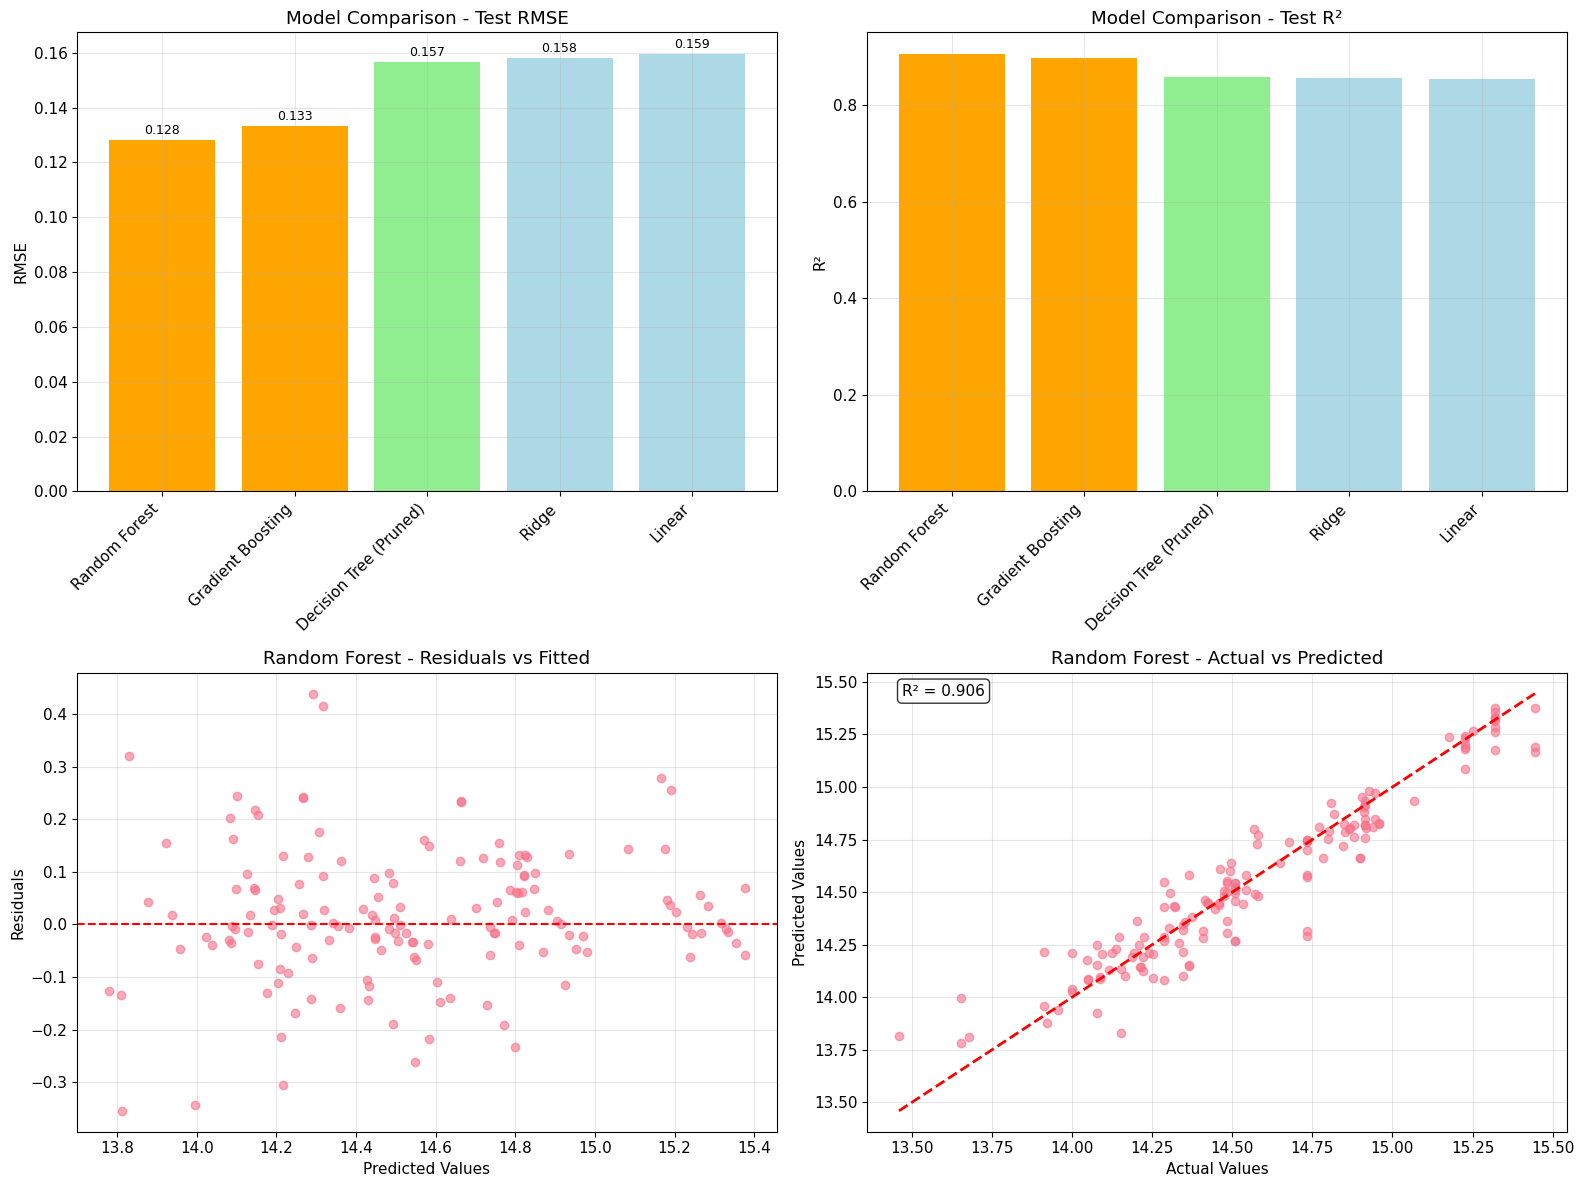

In [20]:
# 6.2 Visualizzazione Finale
print("=== VISUALIZZAZIONE FINALE ===")

# Performance comparison plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: RMSE Comparison
models = comparison_df['Model']
rmses = comparison_df['RMSE']
colors = ['lightblue' if t == 'Linear' else 'lightgreen' if t == 'Tree' else 'orange' 
          for t in comparison_df['Type']]

bars = ax1.bar(range(len(models)), rmses, color=colors)
ax1.set_xticks(range(len(models)))
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.set_ylabel('RMSE')
ax1.set_title('Model Comparison - Test RMSE')
ax1.grid(True, alpha=0.3)

# Aggiungi valori sulle barre
for bar, rmse in zip(bars, rmses):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{rmse:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: R² Comparison
r2s = comparison_df['R²']
ax2.bar(range(len(models)), r2s, color=colors)
ax2.set_xticks(range(len(models)))
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.set_ylabel('R²')
ax2.set_title('Model Comparison - Test R²')
ax2.grid(True, alpha=0.3)

# Plot 3: Residuals for best tree model
best_tree_name = comparison_df[comparison_df['Type'].isin(['Tree', 'Ensemble'])].iloc[0]['Model']
if 'Random Forest' in best_tree_name:
    y_pred_best = best_rf.predict(X_test)
elif 'Gradient' in best_tree_name:
    y_pred_best = best_gb.predict(X_test)
else:
    y_pred_best = pruned_tree.predict(X_test)

residuals = y_test - y_pred_best
ax3.scatter(y_pred_best, residuals, alpha=0.6)
ax3.axhline(y=0, color='red', linestyle='--')
ax3.set_xlabel('Predicted Values')
ax3.set_ylabel('Residuals')
ax3.set_title(f'{best_tree_name} - Residuals vs Fitted')
ax3.grid(True, alpha=0.3)

# Plot 4: Actual vs Predicted for best model
ax4.scatter(y_test, y_pred_best, alpha=0.6)
min_val, max_val = y_test.min(), y_test.max()
ax4.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
ax4.set_xlabel('Actual Values')
ax4.set_ylabel('Predicted Values')
ax4.set_title(f'{best_tree_name} - Actual vs Predicted')
ax4.grid(True, alpha=0.3)

# Aggiungi R² al grafico
r2_best = r2_score(y_test, y_pred_best)
ax4.text(0.05, 0.95, f'R² = {r2_best:.3f}', transform=ax4.transAxes,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()